In [18]:
#!pip install pulp


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
#!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


In [28]:
#import sys
#!{sys.executable} -m pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 5.9 MB/s  0:00:02 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Users/scottkeighley/.venv/bin/python -m pip install --upgrade pip


In [38]:
#import sys
#!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.1 MB/s  0:00:06 eta 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.1 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 289.5 kB/s  0:00:15 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Users/scottkeighley/.venv/bin/python -m pip install --upgrade pip


In [22]:
from pulp import *

# Homework Assignment (Problem Set) 1:

Note, Problem Set 1 directly focuses on Modules 1 and 2; Introduction to Decision Analysis and Formulation and Solving Linear Programs

## Question 1: 

On the Road Again is a local auto garage that employs three mechanics. Each mechanic has a different level of experience and has different tools, so the time (in minutes) and cost (in parts and materials) to perform each of the three services differs (see below). Management has noticed that 20 Service A, 18 Service B, and 15 Service C customers come in each day. Each mechanic works a different schedule, with mechanic 1 working 8 hours per day, mechanic 2 working 6 hours per day, and mechanic 3 working 9 hours per day. Management wants to find the least expensive plan to conduct these services. Develop a linear program to solve this problem. You do not have to solve the LP, but I will provide feedback if you do. Note: Assume it is absolutely fine for a mechanic to perform a partial service (don’t set integer constraints).

Table 1: 

| Repair Technician | | Service A | | Service B | | Service C |
| --- | --- | --- | --- | --- | --- | -- |
| | Cost | Time | Cost | Time | Cost | Time |
| Mechanic 1 | 7 | 20 | 8 | 30 | 9 | 35 |
| Mechanic 2 | 10 | 10 | 12 | 20 | 13 | 25 |
| Mechanic 3 | 6 | 25 | 7 | 35 | 8 | 45 |

### Decision Variables

Variables = $x_{ij}$

$i$ = mechanic (1, 2, 3)

$j$ = service (A, B, C)

9 total variables

### Objective Function

Want to minimize total cost
- Minimize $Z = (cost_{1A})x_{1A}+(cost_{2A})x_{2A}+(cost_{3A})x_{3A}+(cost_{1B})x_{1B}+(cost_{2B})x_{2B}+(cost_{3B})x_{3B}+(cost_{1C})x_{1C}+(cost_{2C})x_{2C}+(cost_{3C})x_{3C}$

### Constraints

Demand Constraints: 
- Service A: $x_{1A} + x_{2A} + x_{3A} \ge 20$
- Service B: $x_{1B} + x_{2B} + x_{3B} \ge 18$
- Service C: $x_{1C} + x_{2C} + x_{3C} \ge 15$

Time Constraints: 
- Mechanic 1: $20x_{1A} + 30x_{1B} + 35x_{1C} \le 480$
- Mechanic 2: $10x_{2A} + 20x_{2B} + 25x_{2C} \le 360$
- Mechanic 3: $25x_{3A} + 35x_{3B} + 45x_{3C} \le 540$

Non-negativity: 
- all variables $\ge 0$


In [6]:
# === Define Data ===
mechanics = [1, 2, 3]
services = ["A", "B", "C"]

cost = {
    1: {"A": 7, "B": 8, "C": 9},
    2: {"A": 10, "B": 12, "C": 13},
    3: {"A": 6, "B": 7, "C": 8}
}

time_req = {
    1: {"A": 20, "B": 30, "C": 35},
    2: {"A": 10, "B": 20, "C": 25},
    3: {"A": 25, "B": 35, "C": 45}
}

minutes_available = {
    1: 480,
    2: 360,
    3: 540
}

demand = {'A': 20, 'B': 18, 'C': 15}

In [7]:
# === Define the problem & decision variables
prob = LpProblem('On_the_Road_Again', LpMinimize)

x = LpVariable.dicts('x', [(i, j) for i in mechanics for j in services], lowBound=0)

print('Decision variables created:')
for key in x: 
    print(f' x{key}')

Decision variables created:
 x(1, 'A')
 x(1, 'B')
 x(1, 'C')
 x(2, 'A')
 x(2, 'B')
 x(2, 'C')
 x(3, 'A')
 x(3, 'B')
 x(3, 'C')


In [8]:
# === Define objective function ===
prob += lpSum(cost[i][j] * x[(i, j)] for i in mechanics for j in services), 'Total Cost'

In [9]:
# === Add Demand constraints === 
for j in services: 
    prob += lpSum(x[(i, j)] for i in mechanics) >= demand[j], f'Demand_{j}'

In [10]:
# === Add Time constraints ===
for i in mechanics: 
    prob += lpSum(time_req[i][j] * x[(i, j)] for j in services) <= minutes_available[i], f'Time_Mechanic_{i}'

In [11]:
print(prob)

On_the_Road_Again:
MINIMIZE
7*x_(1,_'A') + 8*x_(1,_'B') + 9*x_(1,_'C') + 10*x_(2,_'A') + 12*x_(2,_'B') + 13*x_(2,_'C') + 6*x_(3,_'A') + 7*x_(3,_'B') + 8*x_(3,_'C') + 0.0
SUBJECT TO
Demand_A: x_(1,_'A') + x_(2,_'A') + x_(3,_'A') >= 20

Demand_B: x_(1,_'B') + x_(2,_'B') + x_(3,_'B') >= 18

Demand_C: x_(1,_'C') + x_(2,_'C') + x_(3,_'C') >= 15

Time_Mechanic_1: 20 x_(1,_'A') + 30 x_(1,_'B') + 35 x_(1,_'C') <= 480

Time_Mechanic_2: 10 x_(2,_'A') + 20 x_(2,_'B') + 25 x_(2,_'C') <= 360

Time_Mechanic_3: 25 x_(3,_'A') + 35 x_(3,_'B') + 45 x_(3,_'C') <= 540

VARIABLES
x_(1,_'A') Continuous
x_(1,_'B') Continuous
x_(1,_'C') Continuous
x_(2,_'A') Continuous
x_(2,_'B') Continuous
x_(2,_'C') Continuous
x_(3,_'A') Continuous
x_(3,_'B') Continuous
x_(3,_'C') Continuous



In [12]:
# === Solve ===
prob.solve(PULP_CBC_CMD(msg=0))

print(f'Status: {LpStatus[prob.status]}')
print(f'\nMinimum Total Cost: ${value(prob.objective):.2f}')
print('\nOptimal Assigments:')
for i in mechanics:
    for j in services:
        val = x[(i, j)].varValue
        if val > 0:
            print(f' Mechanic {i} performs {val:.2f} of Services {j}')

Status: Optimal

Minimum Total Cost: $465.40

Optimal Assigments:
 Mechanic 1 performs 16.98 of Services A
 Mechanic 1 performs 2.57 of Services B
 Mechanic 1 performs 1.81 of Services C
 Mechanic 2 performs 3.02 of Services A
 Mechanic 2 performs 13.19 of Services C
 Mechanic 3 performs 15.43 of Services B


Minimized cost by relying as much on Mechanic 1 and Mechanic 3 as possible because they are the least expensive. Mechanic 2, who was the most expensive, was used sparingly and only for Services A and C. 

Mechanic 3 was the cheapest but also the slowest. With only 540 minutes available, they hit their time limit quickly so solver had to distribute work to others. 

## Question 2

Consider the following linear program
$$min10x_1-12x_2$$

st.
$$2x_1 + x_2 \ge 5$$
$$-x_1 + 2x_2 \le 7$$
$$4x_1 - 3x_2 \le 15$$
$$x_1 \le 6$$
$$x_i \ge 0$$

Part A: Write the LP in standard equality form (note: not standard form)

Part B: Solve the original LP graphically (to scale). Clearly identify the feasible region and, if one or more exist, the optimal solution(s) (provide exact values for $x_1$, $x_2$, and $Z$)

#### Part A

$$2x_1 + x_2 - s_1 = 5$$
$$-x_1 + 2x_2 + s_2 = 7$$
$$4x_1 - 3x_2 + s_3 = 15$$
$$x_1 + s_4 = 6$$
$$x1, x2, s1, s2, s3, s4 \ge 0$$

$2x_2 = 7 + x_1$

$x_2 = \frac{7+x_1}{2}$

$-3x_2 = 15 - 4x_1$

$x_2 = \frac{15 - 4x_1}{-3}$

In [17]:
-0 + 2*0 <= 7

True

In [18]:
4*0 - 3*0 <= 15

True

In [19]:
0 <= 6

True

#### Part B

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

In [22]:
# == Define Grid and Constraint Lines ===
x1 = np.linspace(0, 10, 400)
x2 = np.linspace(0, 10, 400)
X1, X2 = np.meshgrid(x1, x2)

c1 = 5 - 2*x1          # 2x1 + x2 = 5
c2 = (7 + x1) / 2      # -x1 + 2x2 = 7
c3 = (4*x1 - 15) / 3   # 4x1 - 3x2 = 15

In [23]:
# === Define Feasible Region ===
feasible = (
    (2*X1 + X2 >= 5) &    
    (-X1 + 2*X2 <= 7) &   
    (4*X1 - 3*X2 <= 15) & 
    (X1 <= 6) &            
    (X1 >= 0) &            
    (X2 >= 0)              
)

In [24]:
# === Find Corner Points ===
def find_corner_points(x1_range, x2_range, tol=1e-6):
    """
    Find feasible corner points by checking intersections
    of constraint boundary lines.
    """
    # Define boundary lines 
    lines = [
        (2, 1, 5),    
        (-1, 2, 7),   
        (4, -3, 15),  
        (1, 0, 6),    
        (1, 0, 0),    
        (0, 1, 0),    
    ]

    corners = []
    for (a1,b1,c1), (a2,b2,c2) in combinations(lines, 2):
        A = np.array([[a1,b1],[a2,b2]])
        b = np.array([c1,c2])
        if abs(np.linalg.det(A)) < tol:
            continue  
        pt = np.linalg.solve(A, b)
        x1v, x2v = pt
        
        if (2*x1v + x2v >= 5 - tol and
            -x1v + 2*x2v <= 7 + tol and
            4*x1v - 3*x2v <= 15 + tol and
            x1v <= 6 + tol and
            x1v >= -tol and x2v >= -tol):
            corners.append((round(x1v, 4), round(x2v, 4)))

    unique = []
    for pt in corners:
        if not any(abs(pt[0]-u[0]) < tol and abs(pt[1]-u[1]) < tol for u in unique):
            unique.append(pt)
    return unique

corners = find_corner_points(x1, x2)
print('Corner Points of the Feasible Region:')
for pt in corners:
    z = 10*pt[0] - 12*pt[1]
    print(f'  x1={pt[0]}, x2={pt[1]} --> Z={z:.4f}')

Corner Points of the Feasible Region:
  x1=0.6, x2=3.8 --> Z=-39.6000
  x1=2.5, x2=0.0 --> Z=25.0000
  x1=6.0, x2=6.5 --> Z=-18.0000
  x1=6.0, x2=3.0 --> Z=24.0000
  x1=3.75, x2=0.0 --> Z=37.5000


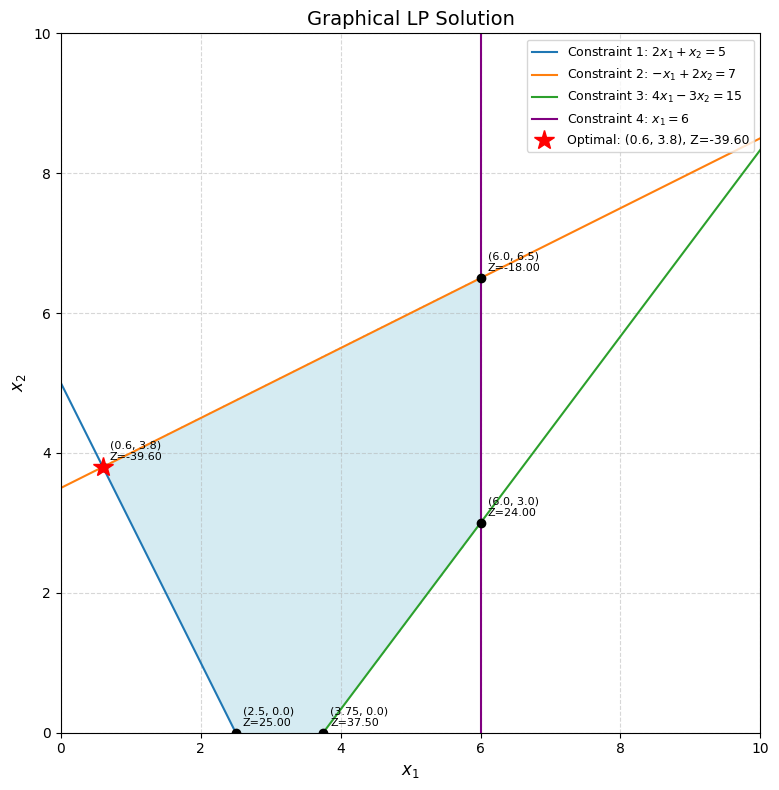


Optimal Solution: x1=0.6, x2=3.8, Z=-39.6000


In [25]:
# === Plot Feasible Region and Find Optimal Solution ===
fig, ax = plt.subplots(figsize=(8, 8))

# Shade feasible region
ax.contourf(X1, X2, feasible.astype(int), levels=[0.5, 1.5],
            colors=['lightblue'], alpha=0.5, zorder=1)

# Plot constraint lines
ax.plot(x1, c1, label=r'Constraint 1: $2x_1 + x_2 = 5$', zorder=2)
ax.plot(x1, c2, label=r'Constraint 2: $-x_1 + 2x_2 = 7$', zorder=2)
ax.plot(x1, c3, label=r'Constraint 3: $4x_1 - 3x_2 = 15$', zorder=2)
ax.axvline(x=6, color='purple', label=r'Constraint 4: $x_1 = 6$', zorder=2)

# Plot and annotate corner points
opt_pt = None
opt_z = float('inf')
for pt in corners:
    z = 10*pt[0] - 12*pt[1]
    ax.plot(pt[0], pt[1], 'ko', markersize=6, zorder=5)
    ax.annotate(f'({pt[0]}, {pt[1]})\nZ={z:.2f}',
                xy=pt, xytext=(pt[0]+0.1, pt[1]+0.1), fontsize=8, zorder=6)
    if z < opt_z:
        opt_z = z
        opt_pt = pt

# Highlight optimal point
ax.plot(opt_pt[0], opt_pt[1], 'r*', markersize=15,
        label=f'Optimal: ({opt_pt[0]}, {opt_pt[1]}), Z={opt_z:.2f}', zorder=7)

# Formatting
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Graphical LP Solution', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'\nOptimal Solution: x1={opt_pt[0]}, x2={opt_pt[1]}, Z={opt_z:.4f}')

In [26]:
2*0.6+3.8==5

True

In [27]:
-1 * 0.6+2*3.8==7

True

$$2x_1 + 3.8 = 5$$
$$2x_1 = 5 - 3.8$$
$$x_1 = 0.6$$

## Question 3

Investment firm Barry’s Bonds is looking to maximize available funds in 5 months. Each month, it receives revenue and has to pay bills, per the table below. Any remaining funds will be invested into short-term bonds and interest for one month is 0.5%, two months is 2%, three months is 4%, and four months is 8% (total - no compounding). Each bond matures in 1, 2, 3, and 4 months, so not all bonds are set to mature in month 5. Barry’s Bonds currently has $1,000 on-hand, which is available in addition to the revenue for month 1. Use linear programming to determine an investment strategy that maximizes available funds at the beginning of month 5. You do not have to solve the LP, but I will provide feedback if you do.

Hint: What is coming in and what is going out each month? What is coming in for month 5?

| Month | Revenue | Bills |
| --- | --- | --- |
| 1 | 500 | 600 |
| 2 | 900 | 400 | 
| 3 | 200 | 650 |
| 4 | 500 | 250 |

Define the Decision Variables
Let $B_{ij}$ = amount invested in month $i$ in a bond that matures in month $j$

Possibilities: 

$B_{11}$, $B_{12}$, $B_{13}$, $B_{14}$, $B_{21}$, $B_{22}$, $B_{23}$, $B_{31}$, $B_{32}$, $B_{41}$

Bond Maturity Months: 

Month 2: $B_{11}$

Month 3: $B_{12}$, $B_{21}$

Month 4: $B_{13}$, $B_{22}$, $B_{31}$

Month 5: $B_{14}$, $B_{23}$, $B_{32}$, $B_{41}$

#### LP

Maximize: 
$$Z = B_{14} * (1.08) + B_{23} * (1.04) + B_{32} * (1.02) + B_{41} * (1.005)$$

Subject to: 

Month 1: $1500 - 600 - B_{11} - B_{12} - B_{13} - B_{14} \ge 0$

Month 2: $900 + B_{11} * (1.005) - 400 - B_{21} - B_{22} - B_{23} \ge 0$

Month 3: $200 + B_{12} * (1.02) + B_{21} * (1.005) - 650 - B_{31} - B_{32} \ge 0$

Month 4: $500 + B_{13} * (1.04) + B_{22} * (1.02) + B_{31} * (1.005) - 250 - B{41} \ge 0$

$B_{ij} \ge 0$


In [60]:
# === Define the Data ===

# interest rates by bond duration
interest = {
    1: 0.005,
    2: 0.02,
    3: 0.04, 
    4: 0.08
}

# Valid bond combinations
bonds = [(1,1), (1, 2), (1,3), (1, 4),
         (2,1), (2, 2), (2, 3),
         (3,1), (3, 2),
         (4,1)]

# Monthly revenue and bills
revenue = {1: 500, 2: 900, 3: 200, 4: 500}
bills = {1: 600, 2: 400, 3: 650, 4: 250}

# Bonds that mature in month 5
month5_bonds = [(i,j) for i,j in bonds if i+j == 5]
print('month 5 maturing bonds:', month5_bonds)

month 5 maturing bonds: [(1, 4), (2, 3), (3, 2), (4, 1)]


In [62]:
# === Define problem & decision variables ===
prob = LpProblem("Barry's Bonds", LpMaximize)

b = LpVariable.dicts("B", bonds, lowBound=0)

print('Decision Variables:')
for key in b: 
    print(f' B{key}')

Decision Variables:
 B(1, 1)
 B(1, 2)
 B(1, 3)
 B(1, 4)
 B(2, 1)
 B(2, 2)
 B(2, 3)
 B(3, 1)
 B(3, 2)
 B(4, 1)


In [64]:
# === Objective Function ===

prob += lpSum(b[(i,j)] * (1 + interest[j]) for i,j in month5_bonds), 'Total_Funds_Month5'

In [66]:
# === Constraints ===

prob += (1000 + revenue[1]
         - bills[1] - lpSum(b[(i,j)] for i,j in bonds if i == 1) >= 0), 'Cash_Flow_Month1'

prob += (revenue[2] + lpSum(b[(i,j)] * (1 + interest[j]) for i,j in bonds if i+j == 2)
         - bills[2] - lpSum(b[(2,j)] for i,j in bonds if i == 2) >= 0), 'Cash_Flow_Month2'

prob += (revenue[3] + lpSum(b[(i,j)] * (1 + interest[j]) for i,j in bonds if i+j == 3)
         - bills[3] - lpSum(b[(3,j)] for i,j in bonds if i == 3) >= 0), 'Cash_Flow_Month3'

prob += (revenue[4] + lpSum(b[(i,j)] * (1 + interest[j]) for i,j in bonds if i+j == 4)
         - bills[4] - lpSum(b[(4,j)] for i,j in bonds if i == 4) >= 0), 'Cash_Flow_Month4'

In [68]:
print(prob)

Barry's_Bonds:
MAXIMIZE
1.08*B_(1,_4) + 1.04*B_(2,_3) + 1.02*B_(3,_2) + 1.005*B_(4,_1) + 0.0
SUBJECT TO
Cash_Flow_Month1: - B_(1,_1) - B_(1,_2) - B_(1,_3) - B_(1,_4) >= -900

Cash_Flow_Month2: 1.005 B_(1,_1) - B_(2,_1) - B_(2,_2) - B_(2,_3) >= -500

Cash_Flow_Month3: 1.02 B_(1,_2) + 1.005 B_(2,_1) - B_(3,_1) - B_(3,_2) >= 450

Cash_Flow_Month4: 1.04 B_(1,_3) + 1.02 B_(2,_2) + 1.005 B_(3,_1) - B_(4,_1)
 >= -250

VARIABLES
B_(1,_1) Continuous
B_(1,_2) Continuous
B_(1,_3) Continuous
B_(1,_4) Continuous
B_(2,_1) Continuous
B_(2,_2) Continuous
B_(2,_3) Continuous
B_(3,_1) Continuous
B_(3,_2) Continuous
B_(4,_1) Continuous



In [70]:
# === Solve ===

prob.solve(PULP_CBC_CMD(msg=0))

print(f'Status: {LpStatus[prob.status]}')
print(f'\nMaximum Funds at Month 5: ${value(prob.objective):,.2f}')
print(f'\nOptimal Investment Strategy:')
for i,j in bonds:
    val = b[(i,j)].varValue
    if val > 0: 
        maturity = i + j
        ret = val * (1 + interest[j])
        print(f' Month {i}, {j}-month bond: Invest ${val:,.2f} -- Returns ${ret:,.2f} in months {maturity}')

Status: Optimal

Maximum Funds at Month 5: $1,277.58

Optimal Investment Strategy:
 Month 1, 4-month bond: Invest $900.00 -- Returns $972.00 in months 5
 Month 2, 1-month bond: Invest $447.76 -- Returns $450.00 in months 3
 Month 2, 3-month bond: Invest $52.24 -- Returns $54.33 in months 5
 Month 4, 1-month bond: Invest $250.00 -- Returns $251.25 in months 5


## Question 4: 

Loopy Doop Paper Hug Factory is a local company that makes and sells paperclips. They can make no more than 60 crates per month and forecast demand for the next four months to be 50, 50, 70, 40. Production cost in the first month will be \\$20 for a crate of paperclips, but due to vendor pricing, the production cost will increase by \\$5 per month (so it will be \\$25 in month 2, \\$30 in month 3, etc.). Loopy Doopy Paper Hug Factory can also store excess production in its inventory, and the labor/space cost per crate are \\$2 each month. That is, if they make 51 crates of paperclips in month 1, they can store the extra crate for \\$2 and use it in month 2. 

#### Part A: 
Formulate an LP to minimize Loopy Doopy Paper Hug Factory's costs to meet demand. 

#### Part B: 
Solve the LP (provide exact values (do not restrict to integer) for all variables and the optimal objective function). 

Demand = 50, 50, 70, 40

Production costs = \\$20, \\$25, \\$30, \\$35

Inventory cost = \\$2 per month

Decision Variables: 

$P_t$ = number of crates produced in month $t$

$I_t$ = number of crates in inventory at end of month $t$

$t$ = 1, 2, 3, 4

Capacity: 

$P_1 \le 60$

$P_2 \le 60$

$P_3 \le 60$

$P_4 \le 60$

Demand: 

Month 1: $P_1 - 50 = I_2$

Month 2: $I_1 + P_2 - 50 = I_2$

Month 3: $I_2 + P_3 - 70 = I_3$

Month 4: $I_3 + P_4 - 40 = 0$

#### Part A: LP

Minimize $Z = 20P_1 + 25P_2 + 30P_3 + 35P_4 + 2I_1 + 2I_2 + 2I_3$

Subject to: 
$$P_1 - 50 = I_1$$
$$I_1 + P_2 - 50 = I_2$$
$$I_2 + P_3 - 70 = I_3$$
$$I_3 + P_4 - 40 = 0$$
$$P_1, P_2, P_3, P_4 \le 60$$
$$P_t, I_t \ge 0$$

In [4]:
# === Define data ===
months = [1, 2, 3, 4]

# Production cost per crate
prod_cost = {1: 20, 2: 25, 3: 30, 4: 35}

# Forecasted demand per month
demand = {1: 50, 2: 50, 3: 70, 4: 40}

# Inventory holding cost per crate / month
inv_cost = 2

# Maximum production capacity per month
capacity = 60

In [6]:
# === Define problem & decision variables ===
prob = LpProblem("Loopy_Doopy_Paper_Hug_Factory", LpMinimize)

P = LpVariable.dicts("P", months, lowBound=0)
I = LpVariable.dicts("I", [1, 2, 3], lowBound=0)

print('Production Variables:', list(P.keys()))
print('Inventory Variables:', list(I.keys()))

Production Variables: [1, 2, 3, 4]
Inventory Variables: [1, 2, 3]


In [8]:
# === Objective function ===
prob += (lpSum(prod_cost[t] * P[t] for t in months) + lpSum(inv_cost * I[t] for t in [1, 2, 3])), 'Total_Cost'

In [10]:
# === Constraints ===

# Capacity constraints
for t in months:
    prob += P[t] <= capacity, f'Capacity_Month{t}'

# Inventory balance constraints
# Month 1
prob += P[1] - demand[1] == I[1], 'Balance_Month1'

# Month 2, 3
for t in [2, 3]:
    prob += I[t-1] + P[t] - demand[t] == I[t], f'Balance_Month{t}'

# Month 4
prob += I[3] + P[4] - demand[4] == 0, 'Balance_Month4'

In [12]:
print(prob)

Loopy_Doopy_Paper_Hug_Factory:
MINIMIZE
2*I_1 + 2*I_2 + 2*I_3 + 20*P_1 + 25*P_2 + 30*P_3 + 35*P_4 + 0.0
SUBJECT TO
Capacity_Month1: P_1 <= 60

Capacity_Month2: P_2 <= 60

Capacity_Month3: P_3 <= 60

Capacity_Month4: P_4 <= 60

Balance_Month1: - I_1 + P_1 = 50

Balance_Month2: I_1 - I_2 + P_2 = 50

Balance_Month3: I_2 - I_3 + P_3 = 70

Balance_Month4: I_3 + P_4 = 40

VARIABLES
I_1 Continuous
I_2 Continuous
I_3 Continuous
P_1 Continuous
P_2 Continuous
P_3 Continuous
P_4 Continuous



In [14]:
# === Solve ===
prob.solve(PULP_CBC_CMD(msg=0))

print(f'Status: {LpStatus[prob.status]}')
print(f'\nMinimum Total Cost: ${value(prob.objective):,.2f}')
print('\nOptimal Production Plan:')
print(f'{"Month":<8} {"Produce":<10} {"Inventory":<12} {"Prod Cost":<12} {"Inv Cost":<10}')
print('-' * 52)
for t in months:
    p_val = P[t].varValue
    i_val = I[t].varValue if t in [1,2,3] else 0
    p_cost = prod_cost[t] * p_val
    i_cost = inv_cost * i_val
    print(f'{t:<8} {p_val:<10.2f} {i_val:<12.2f} ${p_cost:<11.2f} ${i_cost:<10.2f}')

Status: Optimal

Minimum Total Cost: $5,630.00

Optimal Production Plan:
Month    Produce    Inventory    Prod Cost    Inv Cost  
----------------------------------------------------
1        60.00      10.00        $1200.00     $20.00     
2        60.00      20.00        $1500.00     $40.00     
3        60.00      10.00        $1800.00     $20.00     
4        30.00      0.00         $1050.00     $0.00      


## Question 5: 

Clean Claud's Food Emporium, a local grocery store, is building a work schedule for its stockers and has specific requirements over each 24 hour period (shown in the table below). Each stocker must work two consecutive shifts. 

| Shift | Workers |
| --- | --- |
| Midnight - 4am | 7 |
| 4am - 8am | 10 |
| 8am - Noon | 10 |
| Noon - 4pm | 14 |
| 4pm - 8pm | 9 |
| 8pm - Midnight | 5 |

#### Part A: 
Formulate an LP model to minimize the number of workers required to meet requirements. 

#### Part B: 
Solve the LP (provide exact values for all variables and the optimal objective function).

#### Decision Variables 
- $X_1$ = workers starting at Midnight -> covers midnight - 4am and 4am - 8am
- $X_2$ = workers starting at 4am -> covers 4am-8am and 8am-noon
- $X_3$ = workers starting at 8am -> covers 8am-noon and noon-4pm
- $X_4$ = workers starting at noon -> covers noon-4pm and 4pm-8pm
- $X_5$ = workers starting at 4pm -> covers 4pm-8pm and 8pm-midnight
- $X_6$ = workers starting at 8pm -> covers 8pm-midnight and midnight-4am

#### Constraints
| Shift | Requirement | Workers Covering It |
| --- | --- | --- |
| Midnight-4am | 7 | $X_1 + X_6 \ge 7$ |
| 4am-8am | 10 | $X_2 + X_1 \ge 10$ |
| 8am-Noon | 10 | $X_3 + X_2 \ge 10$ |
| Noon-4pm | 14 | $X_4 + X_3 \ge 14$ |
| 4pm-8pm | 9 | $X_5 + X_4 \ge 9$ |
| 8pm-Midnight | 5 | $X_6 + X_5 \ge 5$ |

#### Objective Function
Minimize $Z = X_1 + X_2 + X_3 + X_4 + X_5 + X_6$

$X_1, X_2, X_3, X_4, X_5, X_6 \ge 0$

In [26]:
# === Define Data ===
shifts = [1, 2, 3, 4, 5, 6]

shift_names = {
    1: 'Midnight-4am',
    2: '4am-8am',
    3: '8am-Noon', 
    4: 'Noon-4pm',
    5: '4pm-8pm',
    6: '8pm-Midnight'
}

requirements = {1: 7, 2: 10, 3: 10, 4: 14, 5: 9, 6: 5}

print('Shift Requirements:')
for i in shifts: 
    print(f' Shift {i} ({shift_names[i]}): {requirements[i]} workers')

Shift Requirements:
 Shift 1 (Midnight-4am): 7 workers
 Shift 2 (4am-8am): 10 workers
 Shift 3 (8am-Noon): 10 workers
 Shift 4 (Noon-4pm): 14 workers
 Shift 5 (4pm-8pm): 9 workers
 Shift 6 (8pm-Midnight): 5 workers


In [28]:
# === Define the Problem & Decision Variables ===
prob = LpProblem("Clean_Claud_Food_Emporium", LpMinimize)

X = LpVariable.dicts("X", shifts, lowBound=0)

print('Decision variables created:')
for i in shifts:
    prev = (i - 2) % 6 + 1
    print (f' X{i}: workers starting at {shift_names[i]} (covers shifts {i} and {i % 6 + 1})')

Decision variables created:
 X1: workers starting at Midnight-4am (covers shifts 1 and 2)
 X2: workers starting at 4am-8am (covers shifts 2 and 3)
 X3: workers starting at 8am-Noon (covers shifts 3 and 4)
 X4: workers starting at Noon-4pm (covers shifts 4 and 5)
 X5: workers starting at 4pm-8pm (covers shifts 5 and 6)
 X6: workers starting at 8pm-Midnight (covers shifts 6 and 1)


In [32]:
# === Objective Function ===
prob += lpSum(X[i] for i in shifts), 'Total_Workers'

In [34]:
# === Shift Coverage Constraints ===
for i in shifts:
    prev = (i - 2) % 6 + 1
    prob += X[i] + X[prev] >= requirements[i], f'Shift_{i}'

In [36]:
print(prob)

Clean_Claud_Food_Emporium:
MINIMIZE
1*X_1 + 1*X_2 + 1*X_3 + 1*X_4 + 1*X_5 + 1*X_6 + 0.0
SUBJECT TO
Shift_1: X_1 + X_6 >= 7

Shift_2: X_1 + X_2 >= 10

Shift_3: X_2 + X_3 >= 10

Shift_4: X_3 + X_4 >= 14

Shift_5: X_4 + X_5 >= 9

Shift_6: X_5 + X_6 >= 5

VARIABLES
X_1 Continuous
X_2 Continuous
X_3 Continuous
X_4 Continuous
X_5 Continuous
X_6 Continuous



In [38]:
# === Solve ===
prob.solve(PULP_CBC_CMD(msg=0))

print(f'Status: {LpStatus[prob.status]}')
print(f'\nMinimum Total Workers: {value(prob.objective):.2f}')
print('\nOptimal Schedule:')
print(f'{"Shift":<6} {"Start Time":<20} {"Workers Starting":<20} {"Covers"}')
print('-' * 70)
for i in shifts:
    val = X[i].varValue
    next_shift = i % 6 + 1
    print(f'{i:<6} {shift_names[i]:<20} {val:<20.2f} {shift_names[i]} & {shift_names[next_shift]}')

print('\nShift Coverage Verification:')
print(f'{"Shift":<6} {"Time":<20} {"Required":<12} {"Assigned":<12} {"Met?"}')
print('-' * 60)
for i in shifts:
    prev = (i - 2) % 6 + 1
    assigned = X[i].varValue + X[prev].varValue
    met = 'Y' if assigned >= requirements[i] - 1e-6 else 'N'
    print(f'{i:<6} {shift_names[i]:<20} {requirements[i]:<12} {assigned:<12.2f} {met}')

Status: Optimal

Minimum Total Workers: 29.00

Optimal Schedule:
Shift  Start Time           Workers Starting     Covers
----------------------------------------------------------------------
1      Midnight-4am         2.00                 Midnight-4am & 4am-8am
2      4am-8am              8.00                 4am-8am & 8am-Noon
3      8am-Noon             2.00                 8am-Noon & Noon-4pm
4      Noon-4pm             12.00                Noon-4pm & 4pm-8pm
5      4pm-8pm              0.00                 4pm-8pm & 8pm-Midnight
6      8pm-Midnight         5.00                 8pm-Midnight & Midnight-4am

Shift Coverage Verification:
Shift  Time                 Required     Assigned     Met?
------------------------------------------------------------
1      Midnight-4am         7            7.00         Y
2      4am-8am              10           10.00        Y
3      8am-Noon             10           10.00        Y
4      Noon-4pm             14           14.00        Y
5      4